# California Housing Price Prediction - Final Optimized Model

This notebook implements a high-performance regression pipeline. After exploring the model without socio-economic factors, we are now integrating `median_income` alongside advanced feature engineering to achieve maximum predictive accuracy.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [46]:
housing = pd.read_csv('housing.csv.csv')

# Cleaning the known $500,001 cap to ensure the model learns real price distributions
housing = housing[housing['median_house_value'] < 500001]

print(f"Dataset size after removing capped values: {len(housing)}")
housing.head()

Dataset size after removing capped values: 19675


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Advanced Feature Engineering

Combining socio-economic data (`median_income`) with geographic clusters and property ratios.

In [47]:
# 1. Property Ratios
housing['rooms_per_household'] = housing['total_rooms'] / housing['households']
housing['bedrooms_per_room'] = housing['total_bedrooms'] / housing['total_rooms']
housing['population_per_household'] = housing['population'] / housing['households']

# 2. High-Density Geographic Clustering (20 Clusters)
coords = housing[['latitude', 'longitude']]
kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
housing['proximity_cluster'] = kmeans.fit_predict(coords)

# 3. Cluster-based Price Benchmark (Peer Metric)
cluster_mean_price = housing.groupby('proximity_cluster')['median_house_value'].mean().to_dict()
housing['avg_price_proximity'] = housing['proximity_cluster'].map(cluster_mean_price)

print("Feature Engineering Complete.")

Feature Engineering Complete.


In [48]:
# Handling nulls
housing_clean = housing.dropna().copy()

# Encoding Categorical Variables and cleaning names for XGBoost
X = pd.get_dummies(housing_clean.drop('median_house_value', axis=1))
X.columns = [c.replace('[', '').replace(']', '').replace('<', 'less_than_') for c in X.columns]
y = housing_clean['median_house_value']

# Splitting (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")

Training set: (15580, 18)


In [49]:
# --- 1. Random Forest Regressor ---
rf_model = RandomForestRegressor(n_estimators=200, max_features='sqrt', n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

# --- 2. XGBoost Regressor ---
xgb_model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=7, subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_r2 = r2_score(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("RESULTS COMPARISON")
print("="*30)
print(f"Random Forest - R2: {rf_r2:.4f} | RMSE: ${rf_rmse:,.2f}")
print(f"XGBoost       - R2: {xgb_r2:.4f} | RMSE: ${xgb_rmse:,.2f}")

RESULTS COMPARISON
Random Forest - R2: 0.8062 | RMSE: $43,321.56
XGBoost       - R2: 0.8352 | RMSE: $39,949.45


C:\Users\User\AppData\Local\Temp\ipykernel_27420\3690364226.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df.head(15), palette='flare')


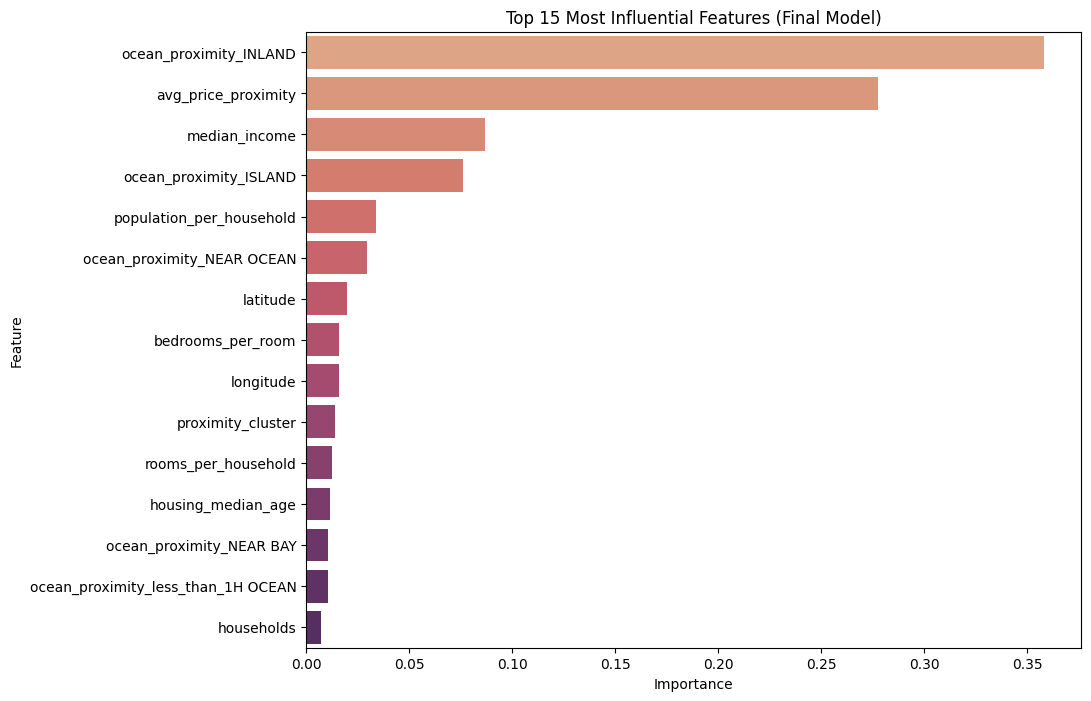

The 'Median Income' and 'Avg Price Proximity' should now dominate the importance ranking.


In [ ]:
# Feature Importance for the best model
best_model = xgb_model if xgb_r2 > rf_r2 else rf_model
importances = best_model.feature_importances_
feature_names = X.columns
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=fi_df.head(15), palette='flare')
plt.title('Top 15 Most Influential Features (Final Model)')
plt.show()
